# Group Members - Group No.28

<table border="1" cellpadding="5" cellspacing="0" style="border-collapse: collapse; text-align: left;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th>Full Name</th>
      <th>Registration Number</th>
      <th>Degree Programme</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>AMON TOROTO</td>
      <td>T24-03-10331</td>
      <td>BSc-CS2</td>
    </tr>
    <tr>
      <td>CHANILA JOSEPH</td>
      <td>T24-03-26045</td>
      <td>BSc-CS2</td>
    </tr>
    <tr>
      <td>GALANDA SWEYA</td>
      <td>T24-03-10322</td>
      <td>BSc-CS2</td>
    </tr>
    <tr>
      <td>RAYMOND MAKUKA</td>
      <td>T24-03-14523</td>
      <td>BSc-CS2</td>
    </tr>
    <tr>
      <td>MUKSINI BUSHIRI</td>
      <td>T24-03-14126</td>
      <td>BSc-CS2</td>
    </tr>
  </tbody>
</table>


# GROUP ASSIGNMENT
Abalone Snail, Machine Learning Case Study
![Abalone Snail Image Sample](./snail.png)

---
**Approach:** Predict Rings directly, then convert to Age (Rings + 1.5)

[GitHub Repository Link](https://github.com/Gsweya/CLASS_CODES/tree/second_yr/sem_two/second_year_code/semester_two/CG%20222%20-%20DATA%20SCIENCE/CLASS_ASSIGNMNENT)

## Importing the Required Libraries

In [47]:
#importing data libraries

# libraries for statistics and data reading 
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error)


## Load the Dataset

In [48]:
df = pd.read_csv("./abalone.data.csv")

# Note: We'll predict Rings directly, then convert to Age at the end
# Age = Rings + 1.5


In [49]:
# Feature Engineering — ratios capture relative body composition
# These normalize each weight component by Whole weight, giving the model
# scale-invariant proportions rather than raw magnitudes. This helps the
# model generalise across abalones of different sizes.
df["Shucked_ratio"] = df["Shucked weight"] / df["Whole weight"]
df["Shell_ratio"] = df["Shell weight"] / df["Whole weight"]
df["Viscera_ratio"] = df["Viscera weight"] / df["Whole weight"]



## Data Preview Of the Data

In [50]:
df.sample(10)

,gender,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Shucked_ratio,Shell_ratio,Viscera_ratio
3773,F,0.575,0.460,0.150,0.9270,0.3330,0.2070,0.2985,9,0.359223,0.322006,0.223301
3910,M,0.455,0.355,0.135,0.4745,0.1865,0.0935,0.1680,13,0.393045,0.354057,0.197050
2533,M,0.630,0.500,0.185,1.3620,0.5785,0.3125,0.3840,10,0.424743,0.281938,0.229442
2975,I,0.320,0.215,0.095,0.3050,0.1400,0.0670,0.0885,6,0.459016,0.290164,0.219672
2018,M,0.505,0.385,0.115,0.4825,0.2100,0.1035,0.1535,10,0.435233,0.318135,0.214508
890,F,0.695,0.560,0.220,1.8340,0.8455,0.4220,0.4550,11,0.461014,0.248092,0.230098
4022,M,0.720,0.545,0.195,1.7475,0.8215,0.3830,0.4705,11,0.470100,0.269242,0.219170
4087,I,0.595,0.475,0.155,0.9840,0.4865,0.1840,0.2755,10,0.494411,0.279980,0.186992
334,F,0.740,0.600,0.195,1.9740,0.5980,0.4085,0.7100,16,0.302938,0.359676,0.206940
1809,F,0.640,0.475,0.140,1.0725,0.4895,0.2295,0.3100,8,0.456410,0.289044,0.213986


## Dataset Strucuture

In [51]:
print(f"There are {df.shape}, rows and columns respectfully")

There are (4177, 12), rows and columns respectfully


### Listed Columns inside the data collected

In [52]:
df.columns

Index(['gender', 'Length', 'Diameter', 'Height', 'Whole weight',
       'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings',
       'Shucked_ratio', 'Shell_ratio', 'Viscera_ratio'],
      dtype='object')

### Nature of the Data Collected (Data Types)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
 9   Shucked_ratio   4177 non-null   float64
 10  Shell_ratio     4177 non-null   float64
 11  Viscera_ratio   4177 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 391.7+ KB


### Checking for missing Values 

In [54]:
df.isnull().sum()


gender            0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
Shucked_ratio     0
Shell_ratio       0
Viscera_ratio     0
dtype: int64

### Statistical Overview of the Data

In [55]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Shucked_ratio,Shell_ratio,Viscera_ratio
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684,0.432414,0.295605,0.218537
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169,0.105765,0.058785,0.034361
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000,0.175258,0.109341,0.007634
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000,0.395100,0.266097,0.198586
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000,0.430592,0.290870,0.217252
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000,0.466175,0.319410,0.236945
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000,4.691943,2.615672,0.665399


### Feature Engineering (ratios + Rings-as-target approach)

We predict **Rings** (integer) instead of Age because:
- Rings is the raw measurement — Age is a linear transform (Rings + 1.5)
- Predicting the integer target avoids injecting the +1.5 constant into the loss function
- At inference time we convert back: Age = predicted Rings + 1.5

## Finding Correlation

In [56]:
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Shucked_ratio,Shell_ratio,Viscera_ratio
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720,0.030147,-0.197950,-0.024799
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660,0.018539,-0.179516,-0.033789
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467,-0.021986,-0.133190,-0.016512
Whole weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390,0.019431,-0.213362,-0.030692
Shucked weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884,0.163885,-0.293407,-0.049985
Viscera weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819,0.005403,-0.235023,0.169291
Shell weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574,-0.059150,-0.006170,-0.067558
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000,-0.211494,0.120111,-0.066942
Shucked_ratio,0.030147,0.018539,-0.021986,0.019431,0.163885,0.005403,-0.059150,-0.211494,1.000000,-0.177935,-0.064893
Shell_ratio,-0.197950,-0.179516,-0.133190,-0.213362,-0.293407,-0.235023,-0.006170,0.120111,-0.177935,1.000000,-0.027803


### Correlation with the Target (Age)

In [57]:
correlation_matrix["Rings"].sort_values(ascending=False)


Rings             1.000000
Shell weight      0.627574
Diameter          0.574660
Height            0.557467
Length            0.556720
Whole weight      0.540390
Viscera weight    0.503819
Shucked weight    0.420884
Shell_ratio       0.120111
Viscera_ratio    -0.066942
Shucked_ratio    -0.211494
Name: Rings, dtype: float64

### Correlation with Rings 

In [58]:
correlation_matrix["Rings"].sort_values(ascending=False)


Rings             1.000000
Shell weight      0.627574
Diameter          0.574660
Height            0.557467
Length            0.556720
Whole weight      0.540390
Viscera weight    0.503819
Shucked weight    0.420884
Shell_ratio       0.120111
Viscera_ratio    -0.066942
Shucked_ratio    -0.211494
Name: Rings, dtype: float64

### Correlation Heatmap

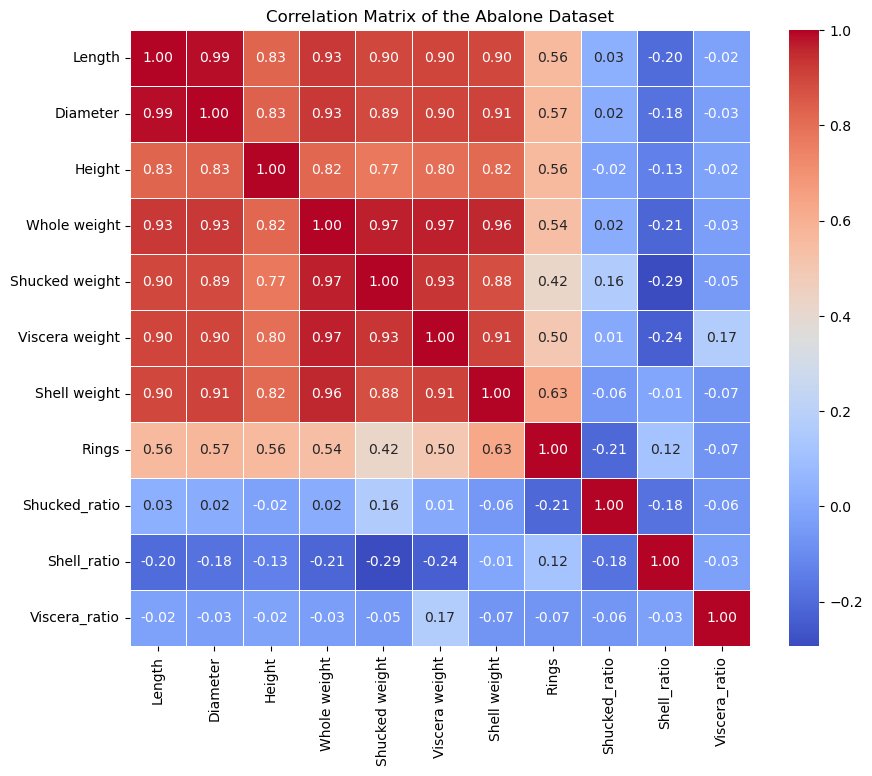

In [59]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of the Abalone Dataset")
plt.show()

### FInding the Outliers

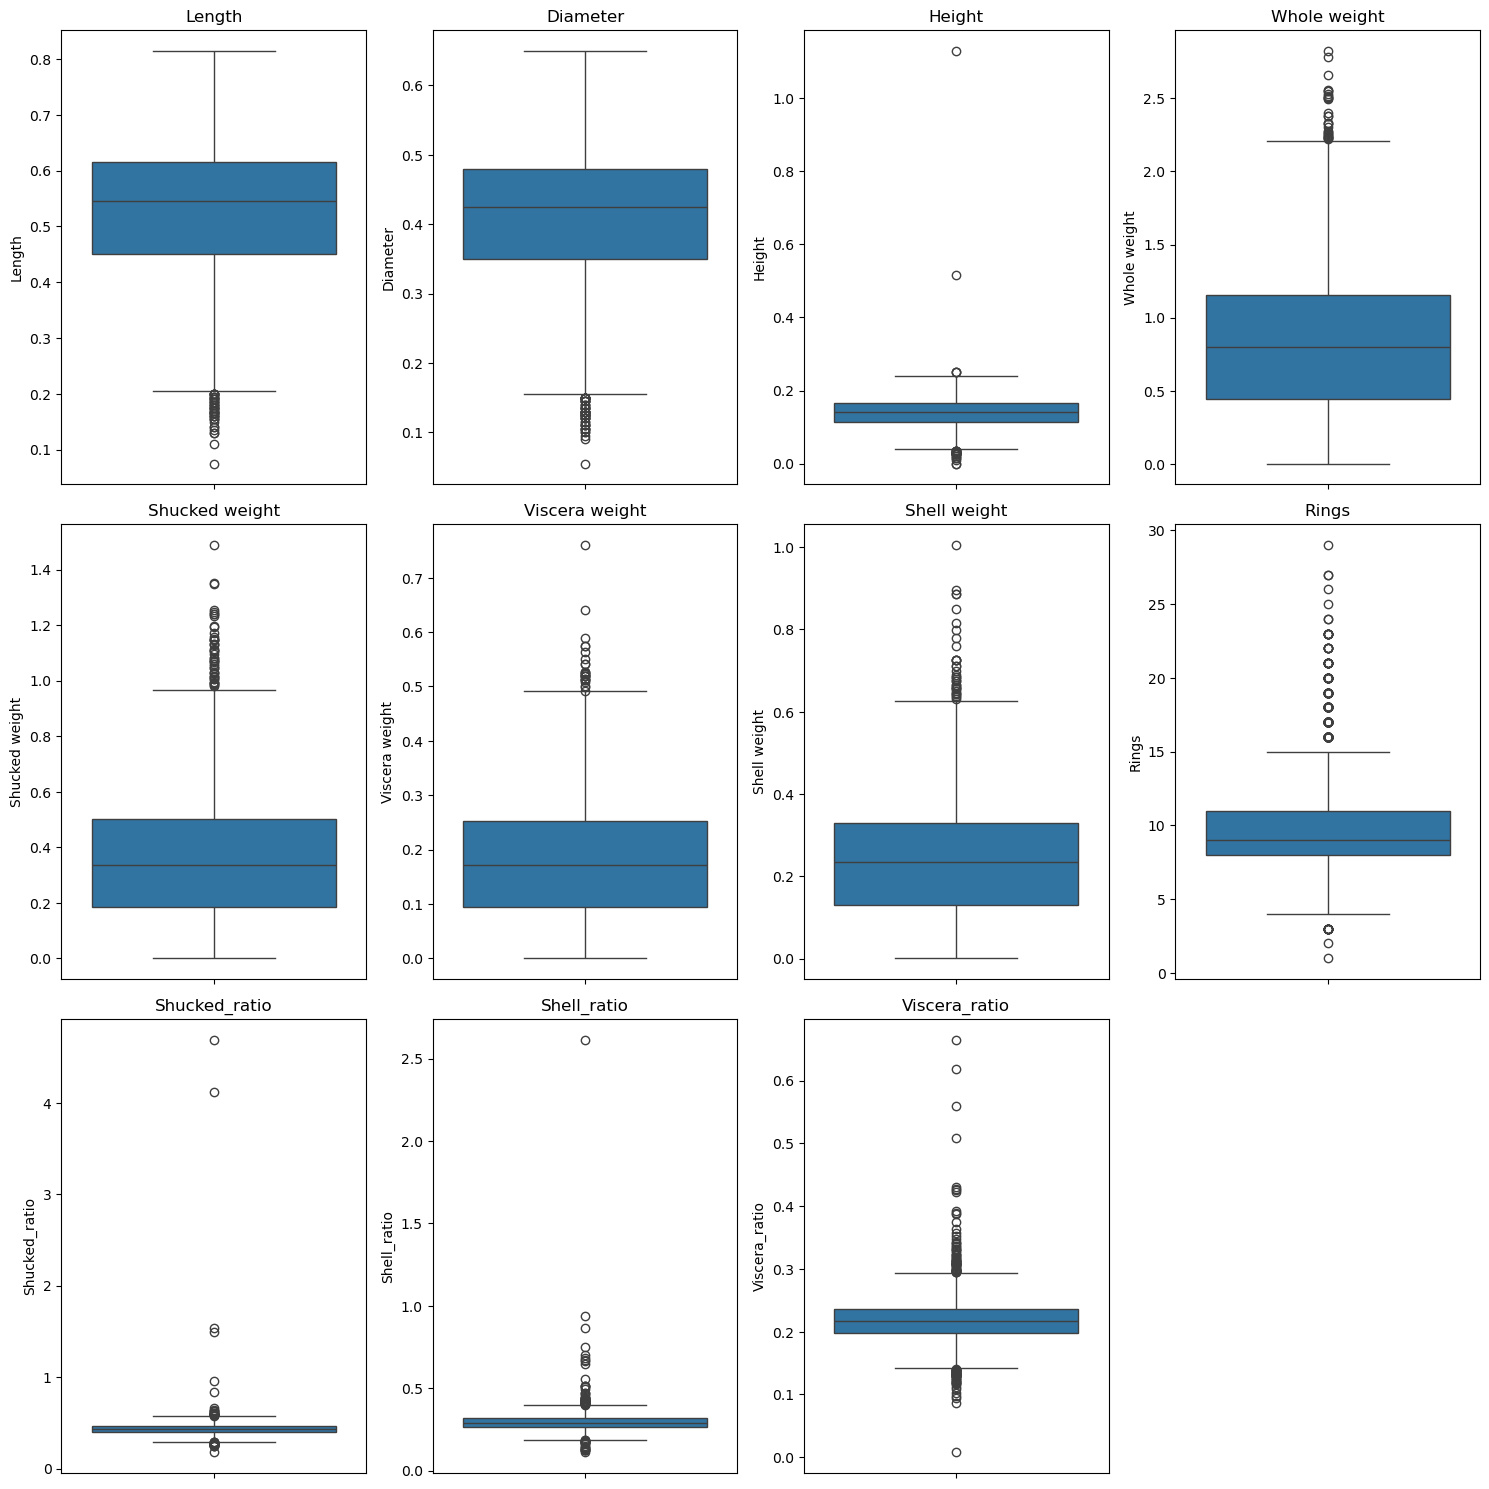

In [60]:
import math
numeric_columns = df.select_dtypes(include="number").columns
n_cols = len(numeric_columns)
cols = 4
rows = math.ceil(n_cols / cols)

plt.figure(figsize=(15, 5 * rows))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()


### Data Cleaning and Removing the Outliers using IQR Method 
Where For below is Q1 - 1.5 x IQR 
For Above 
Q3 + 1.5 x IQR

In [61]:
# Cell 30 — only filter on feature columns, not Age/Rings
feature_cols = df.drop(columns=["Age", "Rings"]).select_dtypes(include="number").columns

Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[
    ~((df[feature_cols] < (Q1 - 1.5 * IQR)) | (df[feature_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]


KeyError: "['Age'] not found in axis"

### Comparing the Data Original and The New Data

In [ ]:
print("Original Dataset Shape :", df.shape)
print("Cleaned Dataset Shape  :", df_clean.shape)

In [ ]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df_clean.select_dtypes(include="number"))

plt.title("Boxplots After Removing Outliers")

plt.xticks(rotation=45)

plt.show()

In [ ]:
correlation_matrix = df_clean.corr(numeric_only=True)
correlation_matrix["Rings"].sort_values(ascending=False)

### Old vs New Correlation Matrices

In [ ]:
# Correlation matrices
corr_before = df.corr(numeric_only=True)
corr_after = df_clean.corr(numeric_only=True)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Before removing outliers
sns.heatmap(
    corr_before,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[0]
)

axes[0].set_title("Before Removing Outliers")

# After removing outliers
sns.heatmap(
    corr_after,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[1]
)

axes[1].set_title("After Removing Outliers")

plt.tight_layout()
plt.show()

# Feature Selection

In [ ]:
# Features (Predictors) — drop both Age and Rings
X = df_clean.drop(columns=["Age", "Rings"])

# Target: Rings (we'll convert to Age at the end)
y = df_clean["Rings"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)


In [ ]:
X.head()

In [ ]:
y.head()

### Data Preprocessing (For non-numericals: Gender)

In [ ]:
categorical_features = ["gender"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ],
    remainder="passthrough"
)

### Split the Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

### Verify the Data Split

In [ ]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

# Model Training

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=10,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

trained_models = {}
predictions = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline
    predictions[name] = pipeline.predict(X_test)

    print(f"{name} trained successfully.")

# Tune Random Forest separately
param_dist = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5]
}

rf_pipeline = Pipeline([("preprocessor", preprocessor), ("model", RandomForestRegressor(random_state=42))])

search = RandomizedSearchCV(rf_pipeline, param_dist, n_iter=20, cv=5, scoring="r2", random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
best_rf = search.best_estimator_
print(search.best_params_, search.best_score_)

trained_models["Random Forest"] = best_rf
predictions["Random Forest"] = best_rf.predict(X_test)
print("Random Forest tuned and trained successfully.")


# Model Evaluation

In [ ]:
results = []

for name, y_pred in predictions.items():

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results.append({
        "Model": name,
        "R² Score": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

# Create comparison table
results_df = pd.DataFrame(results)

# Round values for neat presentation
results_df = results_df.round(4)

# Sorting the Best Model
results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

results_df

# Feature Importance

In [ ]:
rf_model = trained_models["Random Forest"].named_steps["model"]

encoded_features = trained_models["Random Forest"]\
    .named_steps["preprocessor"]\
    .get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

## Plotting Feature Importance

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

# Saving the Model

In [ ]:
import joblib

# Save the best model (Random Forest)
joblib.dump(
    trained_models["Random Forest"],
    "abalone_rings_predictor.pkl"
)

print("Model saved successfully!")


# Load Model and Test

In [ ]:
loaded_model = joblib.load("abalone_rings_predictor.pkl")

new_data = pd.DataFrame({
    "gender": ["M"],
    "Length": [0.55],
    "Diameter": [0.44],
    "Height": [0.15],
    "Whole weight": [0.90],
    "Shucked weight": [0.42],
    "Viscera weight": [0.18],
    "Shell weight": [0.25]
})

# Compute engineered ratio features
new_data["Shucked_ratio"] = new_data["Shucked weight"] / new_data["Whole weight"]
new_data["Shell_ratio"] = new_data["Shell weight"] / new_data["Whole weight"]
new_data["Viscera_ratio"] = new_data["Viscera weight"] / new_data["Whole weight"]

# Predict Rings, then convert to Age
predicted_rings = loaded_model.predict(new_data)
predicted_age = predicted_rings + 1.5

print(f"Predicted Rings: {predicted_rings[0]:.2f}")
print(f"Predicted Age  : {predicted_age[0]:.2f} years")


# Flexible Model Trier

In [ ]:
gender = input("Gender (M/F/I): ")

length = float(input("Length: "))
diameter = float(input("Diameter: "))
height = float(input("Height: "))
whole_weight = float(input("Whole Weight: "))
shucked_weight = float(input("Shucked Weight: "))
viscera_weight = float(input("Viscera Weight: "))
shell_weight = float(input("Shell Weight: "))

new_data = pd.DataFrame({
    "gender": [gender],
    "Length": [length],
    "Diameter": [diameter],
    "Height": [height],
    "Whole weight": [whole_weight],
    "Shucked weight": [shucked_weight],
    "Viscera weight": [viscera_weight],
    "Shell weight": [shell_weight]
})

# Compute engineered ratio features
new_data["Shucked_ratio"] = new_data["Shucked weight"] / new_data["Whole weight"]
new_data["Shell_ratio"] = new_data["Shell weight"] / new_data["Whole weight"]
new_data["Viscera_ratio"] = new_data["Viscera weight"] / new_data["Whole weight"]

# Predict Rings, then convert to Age
predicted_rings = loaded_model.predict(new_data)
predicted_age = predicted_rings + 1.5

print(f"\nPredicted Rings: {predicted_rings[0]:.2f}")
print(f"Predicted Age  : {predicted_age[0]:.2f} years")
